- some stuff here should go to mc statistics notebooks.
- include uncertainties
- add explanations: "generation level contribution"


# String340MC event weights

This notebook loads the oneweight CSVs, splits each flavor into neutrino and antineutrino samples, and builds the normalized weights used for plotting.

In [131]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC")

## Load the flavor files

Each CSV is kept separate at first so the flavor labels stay explicit. The small dictionary below lets the same operation run over all flavors without making one giant cell.

In [132]:
electron_weights = pd.read_csv(DATA_DIR / "Electron_LIW.csv")
muon_weights = pd.read_csv(DATA_DIR / "Muon_LIW.csv")
nc_weights = pd.read_csv(DATA_DIR / "NC_LIW.csv")
tau_weights = pd.read_csv(DATA_DIR / "Tau_LIW.csv")

In [133]:
flavor_weights = {
    "electron": electron_weights,
    "muon": muon_weights,
    "nc": nc_weights,
    "tau": tau_weights,
}

## Split neutrinos and antineutrinos

`initialType > 0` selects neutrinos and `initialType < 0` selects antineutrinos. The split is copied so later weight columns can be added without mutating the raw DataFrames.

In [134]:
def split_neutrino_samples(weights):
    return {
        "neutrino": weights.loc[weights["initialType"] > 0].copy(),
        "antineutrino": weights.loc[weights["initialType"] < 0].copy(),
    }


flavor_splits = {
    flavor: split_neutrino_samples(weights)
    for flavor, weights in flavor_weights.items()
}

In [135]:
electron_neutrino = flavor_splits["electron"]["neutrino"]
electron_antineutrino = flavor_splits["electron"]["antineutrino"]

muon_neutrino = flavor_splits["muon"]["neutrino"]
muon_antineutrino = flavor_splits["muon"]["antineutrino"]

nc_neutrino = flavor_splits["nc"]["neutrino"]
nc_antineutrino = flavor_splits["nc"]["antineutrino"]

tau_neutrino = flavor_splits["tau"]["neutrino"]
tau_antineutrino = flavor_splits["tau"]["antineutrino"]

## Build analysis weights

`oneweight_x100` is the LIW weight scaled by the generated sample size convention used in these files. Here it is converted to `oneweight` by dividing each neutrino or antineutrino subset by its own number of events. After that conversion the original `oneweight_x100` column is dropped so later cells use only the normalized column.

`survivalProb` is the propagation survival probability for the event. The final plotting weight is therefore `final_weight = oneweight * survivalProb`.

In [136]:
def add_analysis_weights(sample):
    if sample.empty:
        raise ValueError("Cannot normalize an empty neutrino sample.")

    weighted = sample.copy()
    weighted["oneweight"] = weighted["oneweight_x100"] / len(weighted)
    weighted = weighted.drop(columns=["oneweight_x100"])
    weighted["final_weight"] = weighted["oneweight"] * weighted["survivalProb"]
    return weighted


weighted_flavor_splits = {
    flavor: {
        particle_type: add_analysis_weights(sample)
        for particle_type, sample in samples.items()
    }
    for flavor, samples in flavor_splits.items()
}

In [137]:
electron_neutrino = weighted_flavor_splits["electron"]["neutrino"]
electron_antineutrino = weighted_flavor_splits["electron"]["antineutrino"]

muon_neutrino = weighted_flavor_splits["muon"]["neutrino"]
muon_antineutrino = weighted_flavor_splits["muon"]["antineutrino"]

nc_neutrino = weighted_flavor_splits["nc"]["neutrino"]
nc_antineutrino = weighted_flavor_splits["nc"]["antineutrino"]

tau_neutrino = weighted_flavor_splits["tau"]["neutrino"]
tau_antineutrino = weighted_flavor_splits["tau"]["antineutrino"]

## Quick checks

This table confirms the split sizes and gives a first look at the normalized weight scale for every flavor and particle type.

In [138]:
summary_rows = []

for flavor, samples in weighted_flavor_splits.items():
    for particle_type, sample in samples.items():
        summary_rows.append(
            {
                "flavor": flavor,
                "particle_type": particle_type,
                "n_events": len(sample),
                "oneweight_min": sample["oneweight"].min(),
                "oneweight_median": sample["oneweight"].median(),
                "oneweight_max": sample["oneweight"].max(),
                "final_weight_min": sample["final_weight"].min(),
                "final_weight_median": sample["final_weight"].median(),
                "final_weight_max": sample["final_weight"].max(),
            }
        )

weight_summary = pd.DataFrame(summary_rows)
weight_summary

,flavor,particle_type,n_events,oneweight_min,oneweight_median,oneweight_max,final_weight_min,final_weight_median,final_weight_max
0,electron,neutrino,686609,14.773224,747.310102,2.158010e+11,14.820518,747.507408,2.140686e+11
1,electron,antineutrino,684900,1.542465,368.413638,2.204917e+11,1.550063,369.167992,2.205808e+11
2,muon,neutrino,975991,10.464847,552.684413,1.763489e+13,10.500835,552.528556,1.768806e+13
3,muon,antineutrino,964338,1.099255,270.243702,1.779140e+13,1.104630,270.844816,1.663207e+13
4,nc,neutrino,998786,3.163107,160.713093,5.695684e+10,3.172766,160.741706,5.701643e+10
5,nc,antineutrino,999483,1.800244,97.180487,5.502448e+10,1.807218,97.321061,5.441184e+10
6,tau,neutrino,997251,10.171377,516.266037,1.581606e+11,10.206434,516.625604,1.584979e+11
7,tau,antineutrino,995304,1.115711,253.865557,1.525825e+11,1.121211,254.387305,1.461833e+11


## Zenith distributions by flavor

For these plots, neutrino and antineutrino rows are combined inside each flavor. The first panel is the raw generated `zenith` distribution, the second panel weights the same zenith histogram with `oneweight`, and the third panel weights it with `final_weight`.

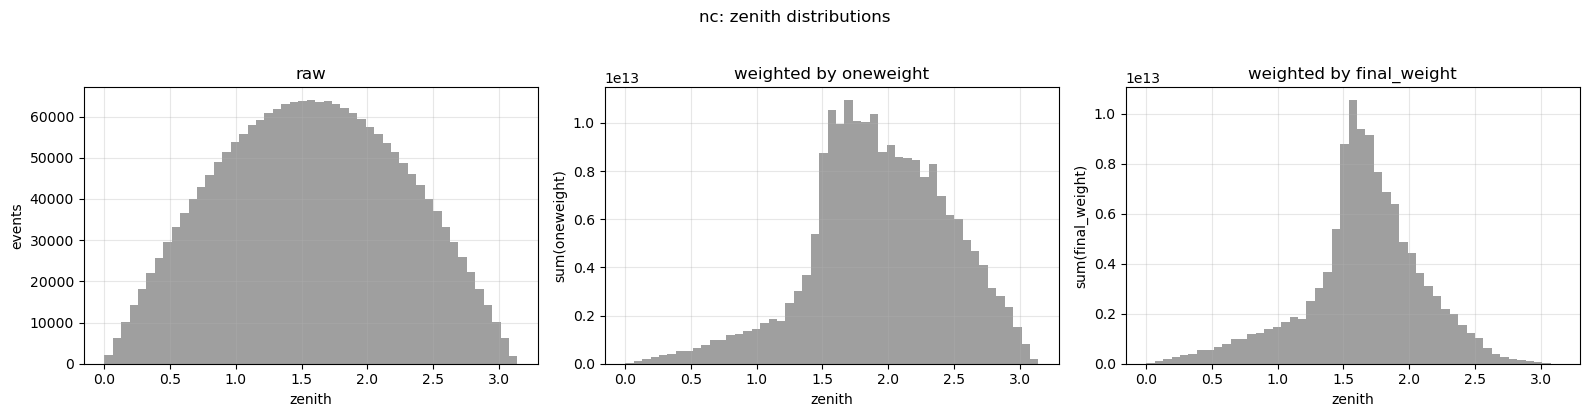

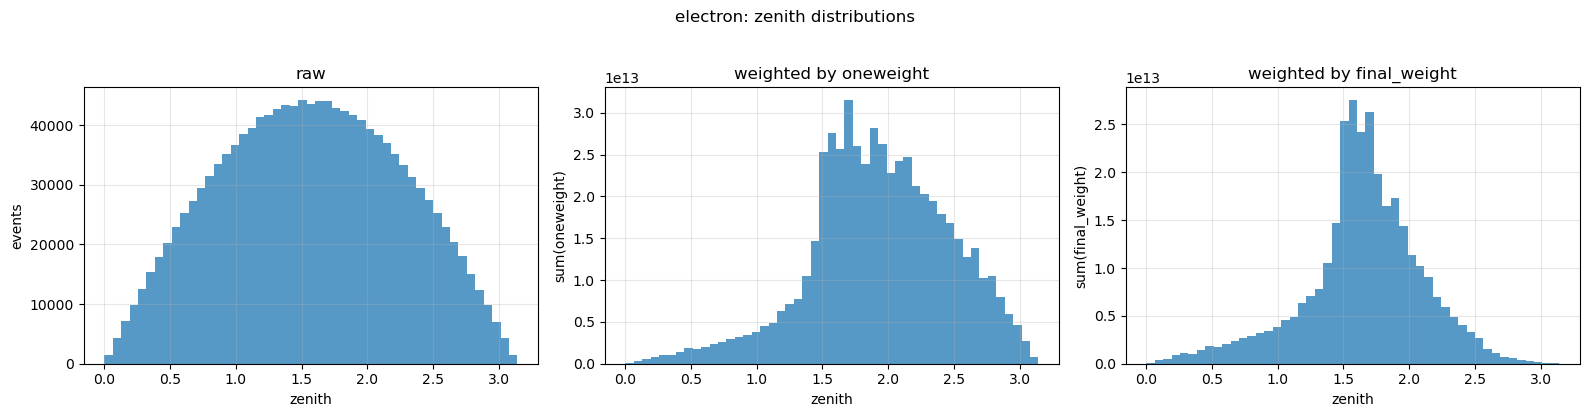

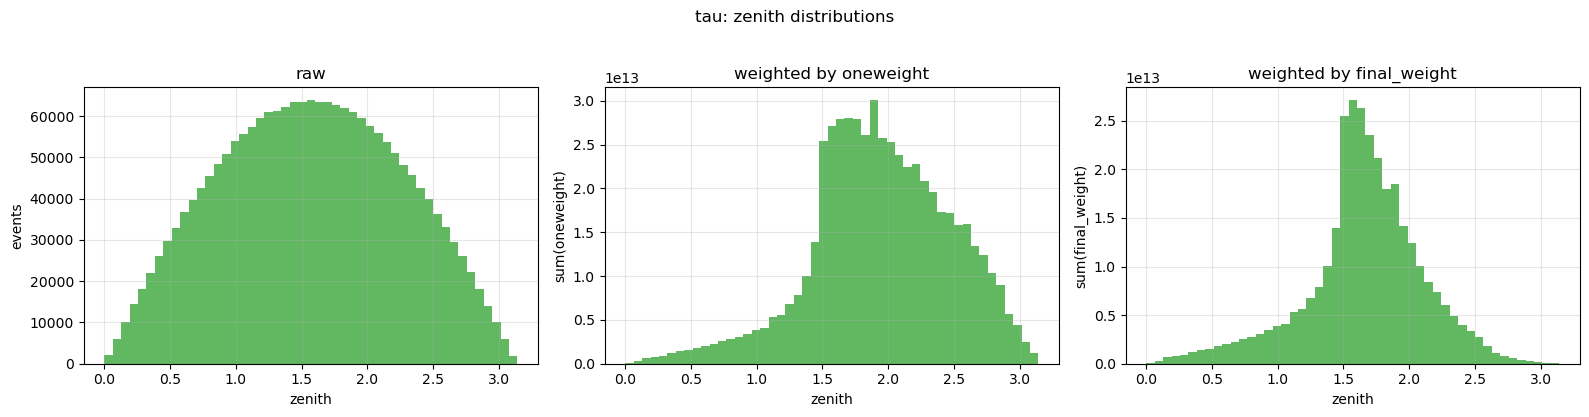

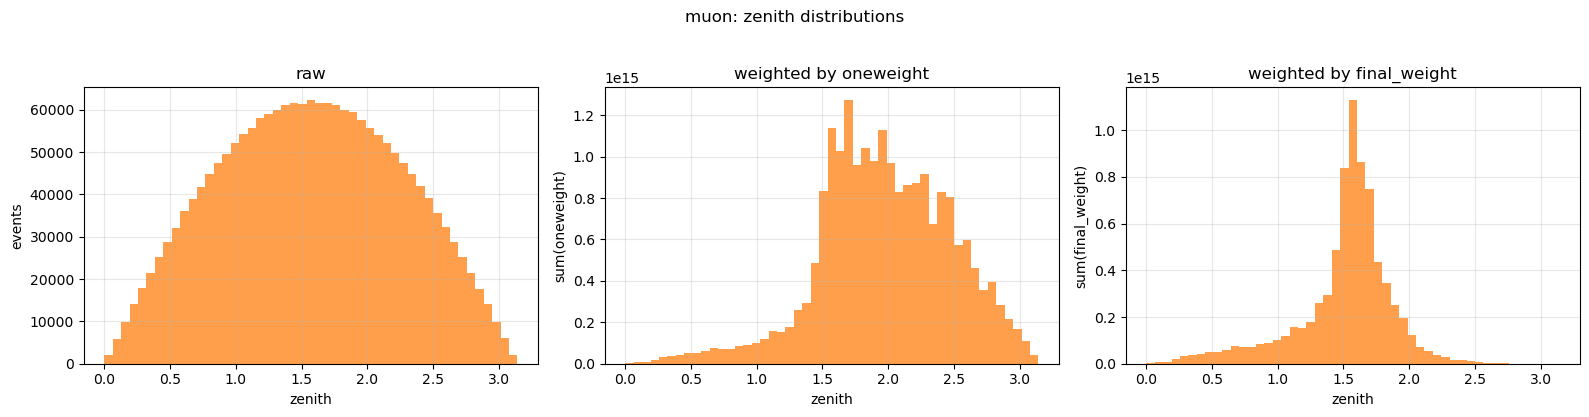

In [139]:
flavor_plot_order = ["nc", "electron", "tau", "muon"]
flavor_colors = {
    "nc": "tab:gray",
    "electron": "tab:blue",
    "tau": "tab:green",
    "muon": "tab:orange",
}

zenith_bins = np.linspace(
    min(
        sample["zenith"].min()
        for samples in weighted_flavor_splits.values()
        for sample in samples.values()
    ),
    max(
        sample["zenith"].max()
        for samples in weighted_flavor_splits.values()
        for sample in samples.values()
    ),
    50,
)

for flavor in flavor_plot_order:
    color = flavor_colors[flavor]
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    fig.suptitle(f"{flavor}: zenith distributions", y=1.03)

    axes[0].hist(
        flavor_sample["zenith"],
        bins=zenith_bins,
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[0].set_title("raw")
    axes[0].set_ylabel("events")

    axes[1].hist(
        flavor_sample["zenith"],
        bins=zenith_bins,
        weights=flavor_sample["oneweight"],
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[1].set_title("weighted by oneweight")
    axes[1].set_ylabel("sum(oneweight)")

    axes[2].hist(
        flavor_sample["zenith"],
        bins=zenith_bins,
        weights=flavor_sample["final_weight"],
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[2].set_title("weighted by final_weight")
    axes[2].set_ylabel("sum(final_weight)")

    for ax in axes:
        ax.set_xlabel("zenith")

    plt.tight_layout()
    plt.show()

## Cosine zenith distributions by flavor

This is the `cos(zenith)` version of the zenith distribution check: raw event counts, `oneweight`-weighted sums, and `final_weight`-weighted sums.

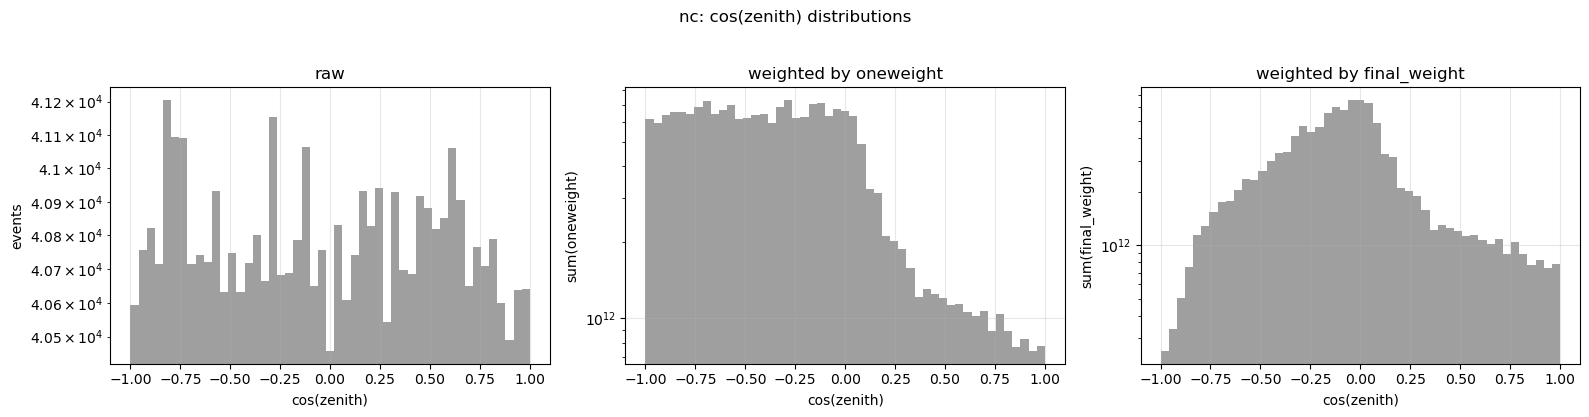

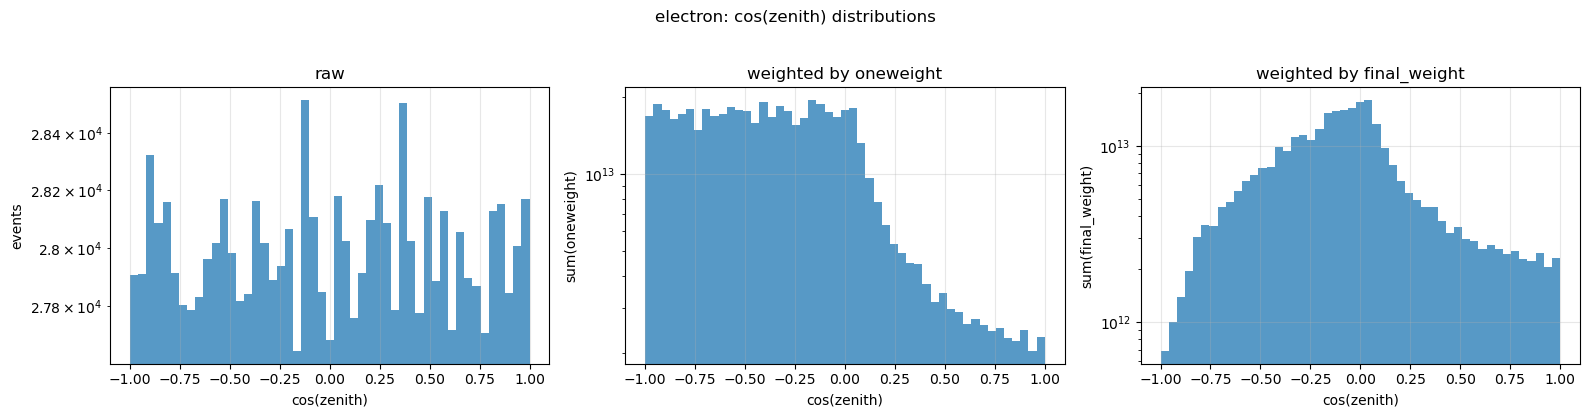

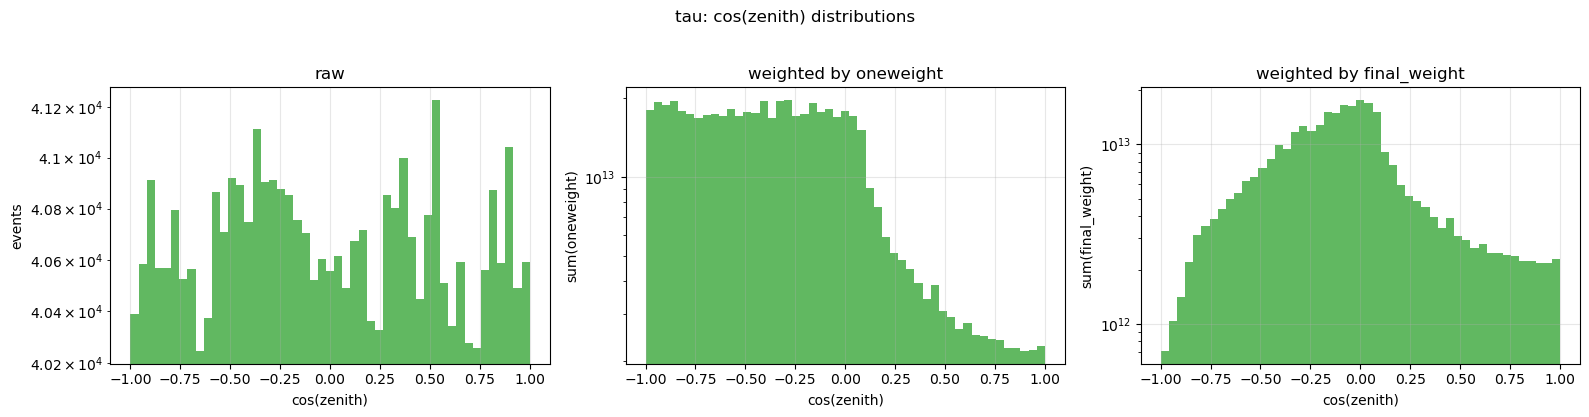

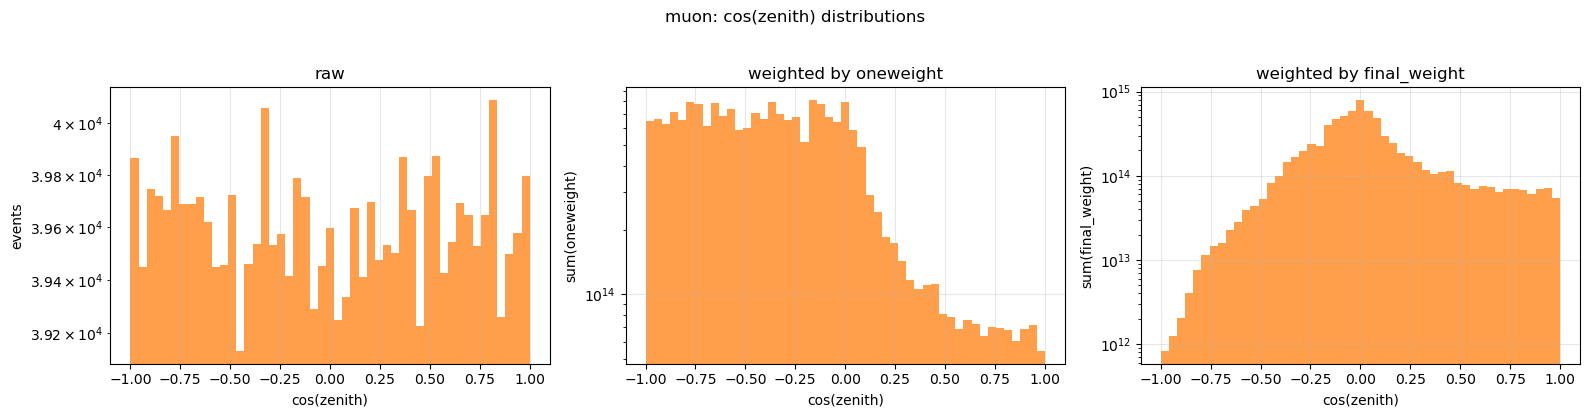

In [140]:
cos_zenith_bins = np.linspace(-1, 1, 50)

for flavor in flavor_plot_order:
    color = flavor_colors[flavor]
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    ).copy()
    flavor_sample["cos_zenith"] = np.cos(flavor_sample["zenith"])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    fig.suptitle(f"{flavor}: cos(zenith) distributions", y=1.03)

    axes[0].hist(
        flavor_sample["cos_zenith"],
        bins=cos_zenith_bins,
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[0].set_title("raw")
    axes[0].set_ylabel("events")

    axes[1].hist(
        flavor_sample["cos_zenith"],
        bins=cos_zenith_bins,
        weights=flavor_sample["oneweight"],
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[1].set_title("weighted by oneweight")
    axes[1].set_ylabel("sum(oneweight)")

    axes[2].hist(
        flavor_sample["cos_zenith"],
        bins=cos_zenith_bins,
        weights=flavor_sample["final_weight"],
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[2].set_title("weighted by final_weight")
    axes[2].set_ylabel("sum(final_weight)")

    for ax in axes:
        ax.set_xlabel("cos(zenith)")
        ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

## Oneweight distributions by flavor

This is the `oneweight` version of the comparison: neutrino and antineutrino are combined for each flavor, then the `oneweight` distributions are drawn with the same flavor colors.

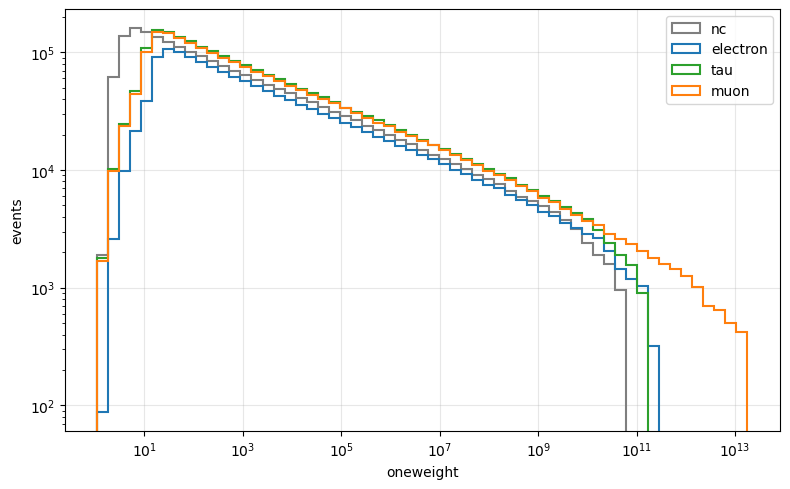

In [141]:
positive_oneweights = []

for flavor in flavor_plot_order:
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )
    positive_oneweights.append(flavor_sample.loc[flavor_sample["oneweight"] > 0, "oneweight"])

oneweight_values = pd.concat(positive_oneweights, ignore_index=True)
oneweight_bins = np.logspace(
    np.log10(oneweight_values.min()),
    np.log10(oneweight_values.max()),
    60,
)

plt.figure(figsize=(8, 5))

for flavor in flavor_plot_order:
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )
    weights = flavor_sample.loc[flavor_sample["oneweight"] > 0, "oneweight"]
    plt.hist(
        weights,
        bins=oneweight_bins,
        histtype="step",
        linewidth=1.5,
        color=flavor_colors[flavor],
        label=flavor,
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("oneweight")
plt.ylabel("events")
plt.legend()
plt.tight_layout()
plt.show()

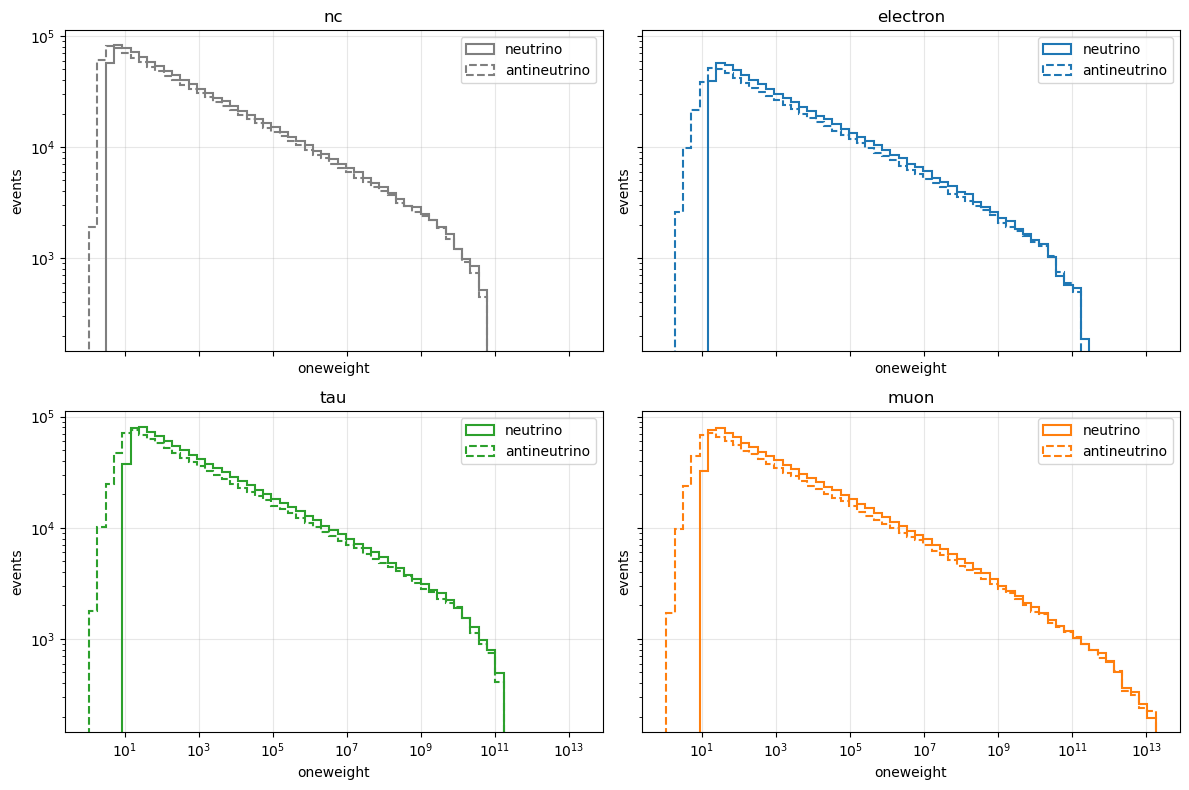

In [142]:
positive_oneweights = [
    sample.loc[sample["oneweight"] > 0, "oneweight"]
    for samples in weighted_flavor_splits.values()
    for sample in samples.values()
]
oneweight_values = pd.concat(positive_oneweights, ignore_index=True)
oneweight_bins = np.logspace(
    np.log10(oneweight_values.min()),
    np.log10(oneweight_values.max()),
    60,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, flavor in zip(axes, flavor_plot_order):
    for particle_type, linestyle in [("neutrino", "-"), ("antineutrino", "--")]:
        sample = weighted_flavor_splits[flavor][particle_type]
        weights = sample.loc[sample["oneweight"] > 0, "oneweight"]
        ax.hist(
            weights,
            bins=oneweight_bins,
            histtype="step",
            linewidth=1.5,
            linestyle=linestyle,
            color=flavor_colors[flavor],
            label=particle_type,
        )

    ax.set_title(flavor)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("oneweight")
    ax.set_ylabel("events")
    ax.legend()

plt.tight_layout()
plt.show()

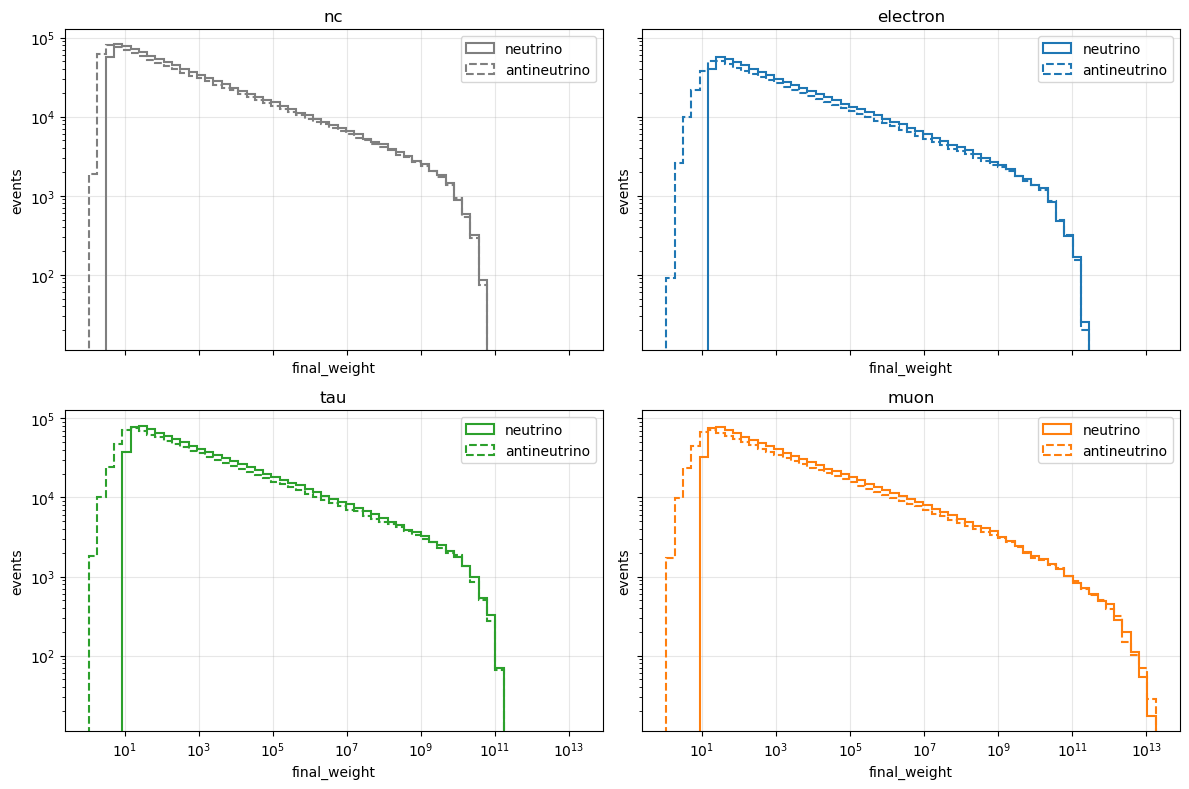

In [143]:
positive_final_weights = [
    sample.loc[sample["final_weight"] > 0, "final_weight"]
    for samples in weighted_flavor_splits.values()
    for sample in samples.values()
]
final_weight_values = pd.concat(positive_final_weights, ignore_index=True)
final_weight_bins = np.logspace(
    np.log10(final_weight_values.min()),
    np.log10(final_weight_values.max()),
    60,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, flavor in zip(axes, flavor_plot_order):
    for particle_type, linestyle in [("neutrino", "-"), ("antineutrino", "--")]:
        sample = weighted_flavor_splits[flavor][particle_type]
        weights = sample.loc[sample["final_weight"] > 0, "final_weight"]
        ax.hist(
            weights,
            bins=final_weight_bins,
            histtype="step",
            linewidth=1.5,
            linestyle=linestyle,
            color=flavor_colors[flavor],
            label=particle_type,
        )

    ax.set_title(flavor)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("final_weight")
    ax.set_ylabel("events")
    ax.legend()

plt.tight_layout()
plt.show()

## Weight vs energy by flavor

Each flavor is plotted separately. The left panel shows `oneweight` vs `energy`; the right panel shows `final_weight` vs `energy`. The orange points are median weights in log-energy bins, and the line is a power-law fit to those medians.

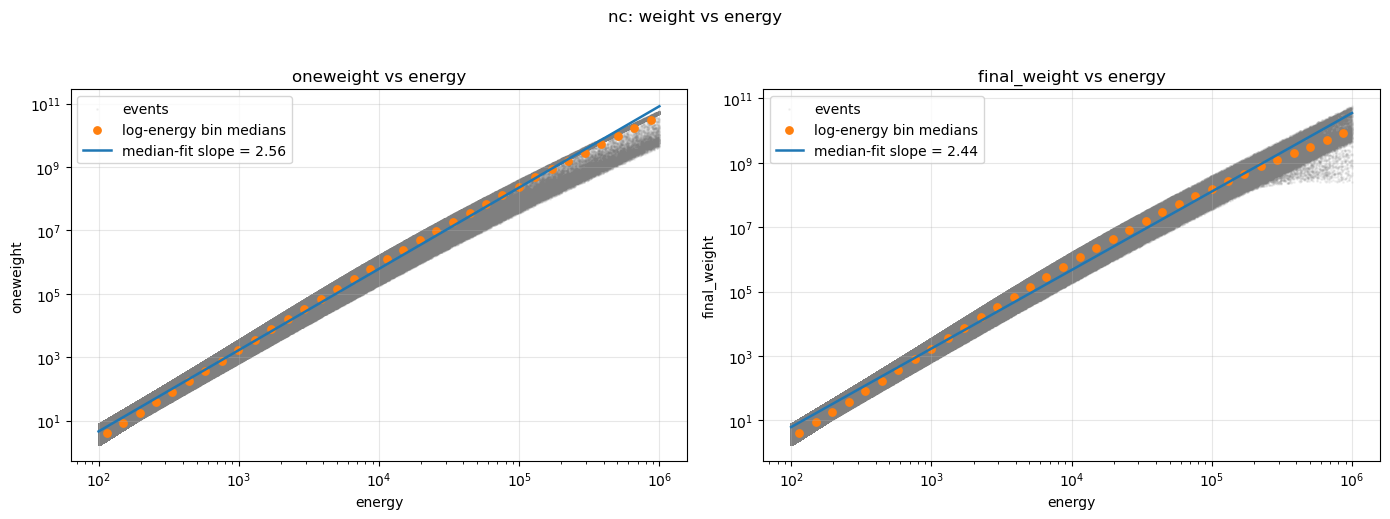

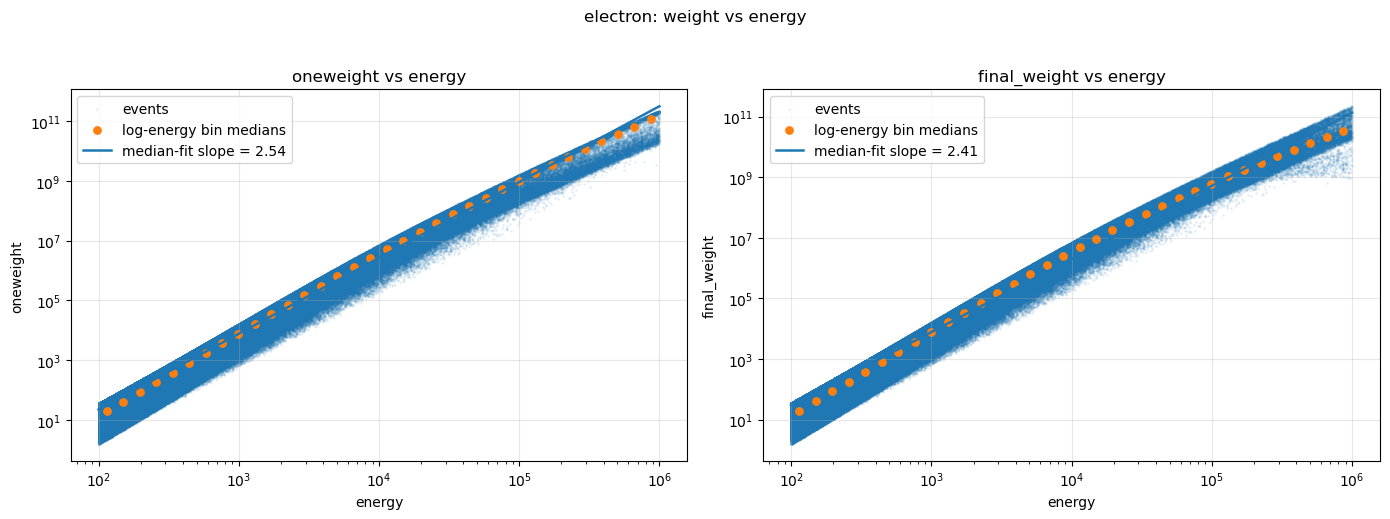

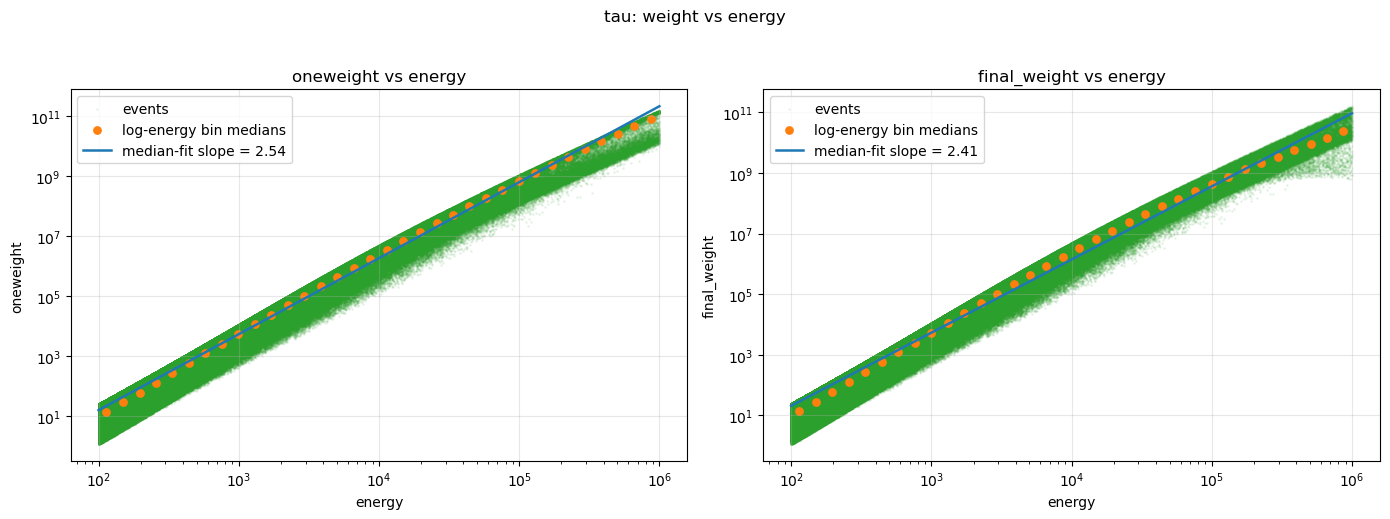

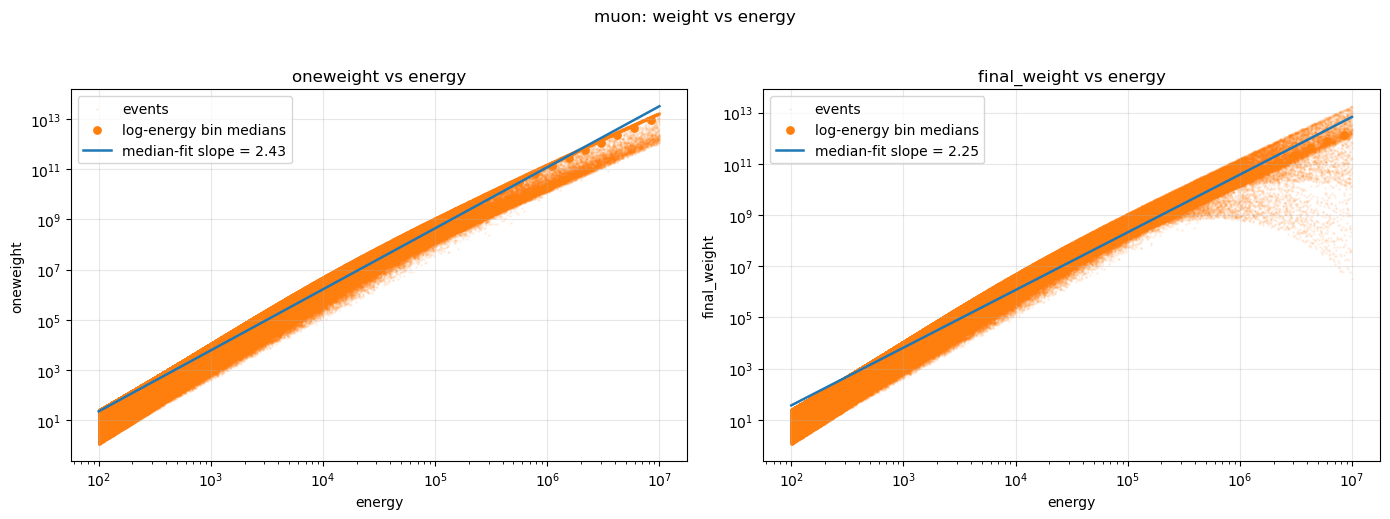

In [144]:
def binned_log_median_fit(energy, weight, bins, min_count=20):
    valid = (energy > 0) & (weight > 0)
    energy = energy.loc[valid]
    weight = weight.loc[valid]

    log_energy = np.log10(energy)
    log_weight = np.log10(weight)
    bin_index = np.digitize(log_energy, bins) - 1

    x_medians = []
    y_medians = []

    for i in range(len(bins) - 1):
        in_bin = bin_index == i
        if in_bin.sum() < min_count:
            continue

        x_medians.append(np.median(log_energy.loc[in_bin]))
        y_medians.append(np.median(log_weight.loc[in_bin]))

    x_medians = np.array(x_medians)
    y_medians = np.array(y_medians)
    slope, intercept = np.polyfit(x_medians, y_medians, 1)
    return slope, intercept, x_medians, y_medians


def plot_weight_vs_energy(ax, sample, weight_column, color):
    plot_sample = sample.loc[(sample["energy"] > 0) & (sample[weight_column] > 0)].copy()
    log_energy = np.log10(plot_sample["energy"])
    bins = np.linspace(log_energy.min(), log_energy.max(), 35)

    slope, intercept, x_medians, y_medians = binned_log_median_fit(
        plot_sample["energy"],
        plot_sample[weight_column],
        bins,
    )
    energy_range = np.logspace(log_energy.min(), log_energy.max(), 200)
    fit_values = 10**intercept * energy_range**slope

    ax.scatter(
        plot_sample["energy"],
        plot_sample[weight_column],
        s=1,
        alpha=0.08,
        color=color,
        label="events",
    )
    ax.scatter(
        10**x_medians,
        10**y_medians,
        s=28,
        color="tab:orange",
        label="log-energy bin medians",
    )
    ax.plot(
        energy_range,
        fit_values,
        color="tab:blue",
        linewidth=1.8,
        label=f"median-fit slope = {slope:.2f}",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("energy")
    ax.set_ylabel(weight_column)
    ax.legend()


for flavor in flavor_plot_order:
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    fig.suptitle(f"{flavor}: weight vs energy", y=1.03)

    plot_weight_vs_energy(axes[0], flavor_sample, "oneweight", flavor_colors[flavor])
    axes[0].set_title("oneweight vs energy")

    plot_weight_vs_energy(axes[1], flavor_sample, "final_weight", flavor_colors[flavor])
    axes[1].set_title("final_weight vs energy")

    plt.tight_layout()
    plt.show()

## Energy distributions by flavor

This mirrors the zenith distribution check: raw generated energy, the same energy histogram weighted by `oneweight`, and the same energy histogram weighted by `final_weight`.

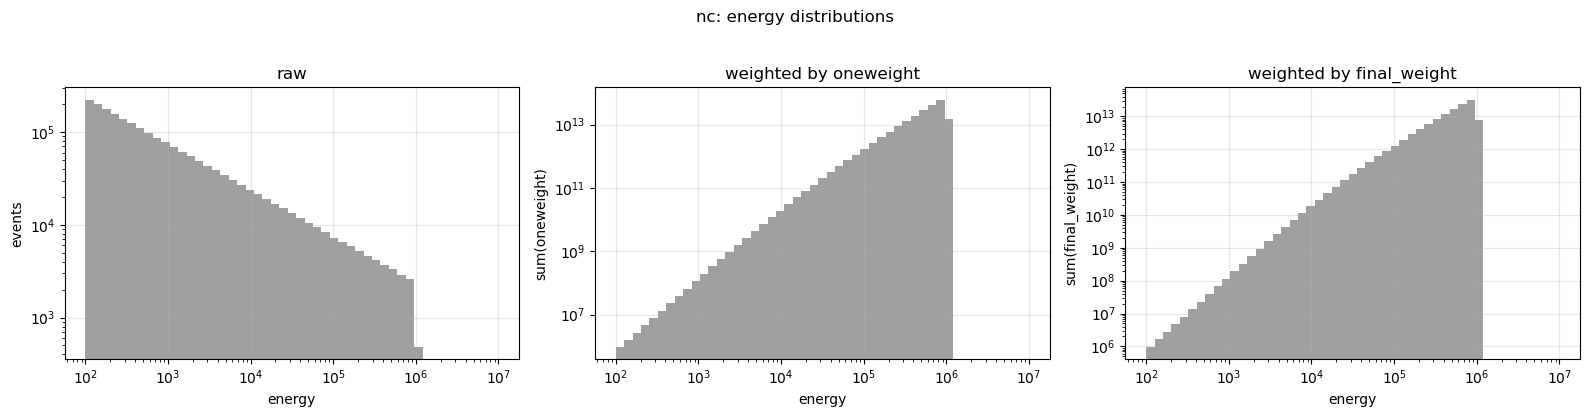

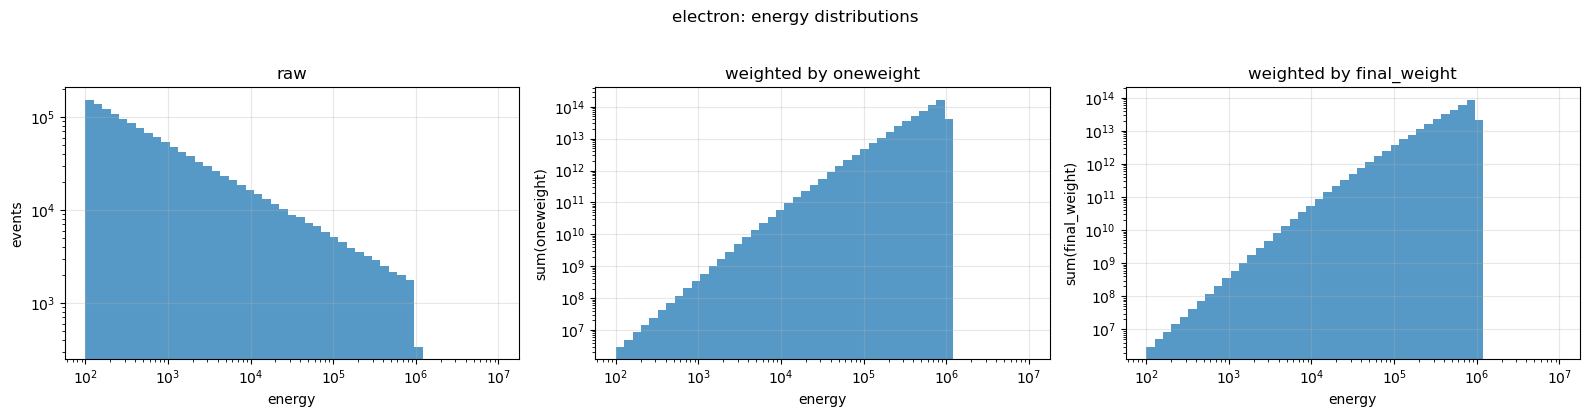

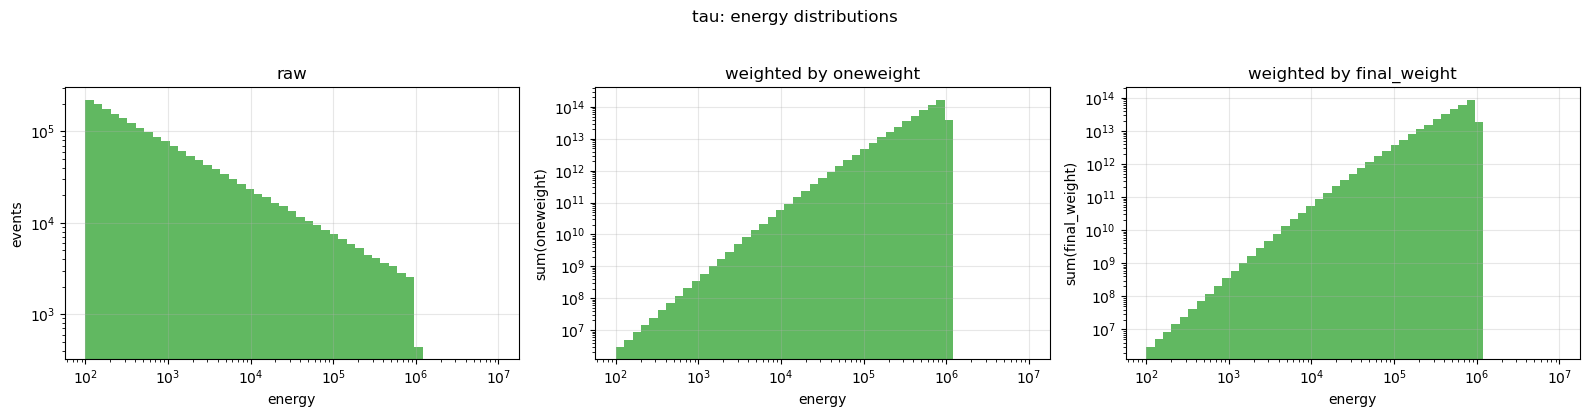

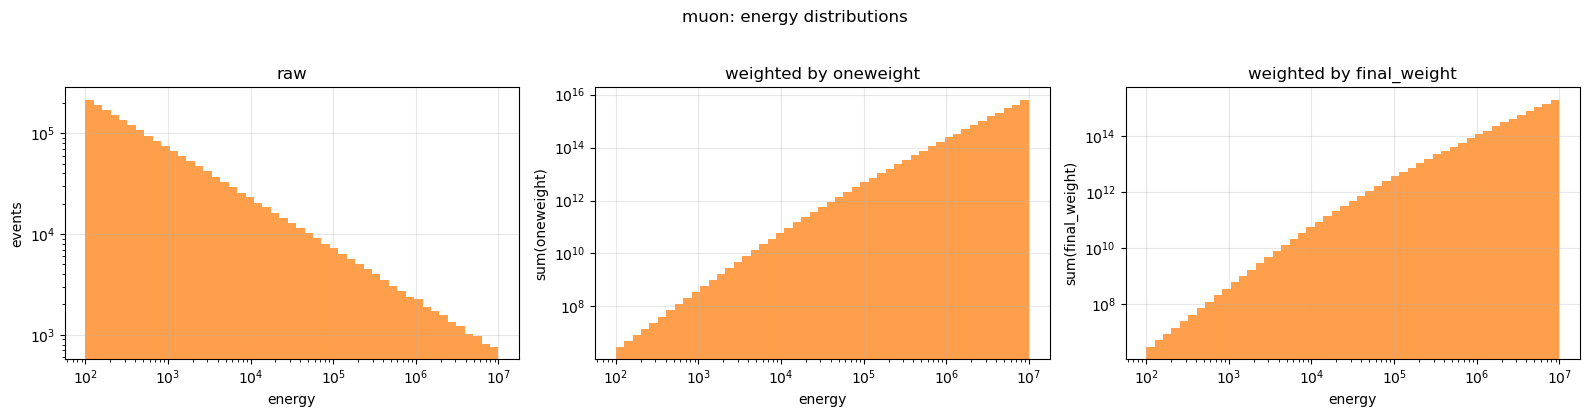

In [145]:
positive_energies = [
    sample.loc[sample["energy"] > 0, "energy"]
    for samples in weighted_flavor_splits.values()
    for sample in samples.values()
]
energy_values = pd.concat(positive_energies, ignore_index=True)
energy_bins = np.logspace(
    np.log10(energy_values.min()),
    np.log10(energy_values.max()),
    50,
)

for flavor in flavor_plot_order:
    color = flavor_colors[flavor]
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )
    flavor_sample = flavor_sample.loc[flavor_sample["energy"] > 0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    fig.suptitle(f"{flavor}: energy distributions", y=1.03)

    axes[0].hist(
        flavor_sample["energy"],
        bins=energy_bins,
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[0].set_title("raw")
    axes[0].set_ylabel("events")

    axes[1].hist(
        flavor_sample["energy"],
        bins=energy_bins,
        weights=flavor_sample["oneweight"],
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[1].set_title("weighted by oneweight")
    axes[1].set_ylabel("sum(oneweight)")

    axes[2].hist(
        flavor_sample["energy"],
        bins=energy_bins,
        weights=flavor_sample["final_weight"],
        histtype="stepfilled",
        color=color,
        alpha=0.75,
    )
    axes[2].set_title("weighted by final_weight")
    axes[2].set_ylabel("sum(final_weight)")

    for ax in axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("energy")

    plt.tight_layout()
    plt.show()

## Generated energy spectrum by flavor

This uses the raw generated energy counts divided by bin width, `dN/dE = counts / dE`, so the slope can be compared directly to the generated power-law index.

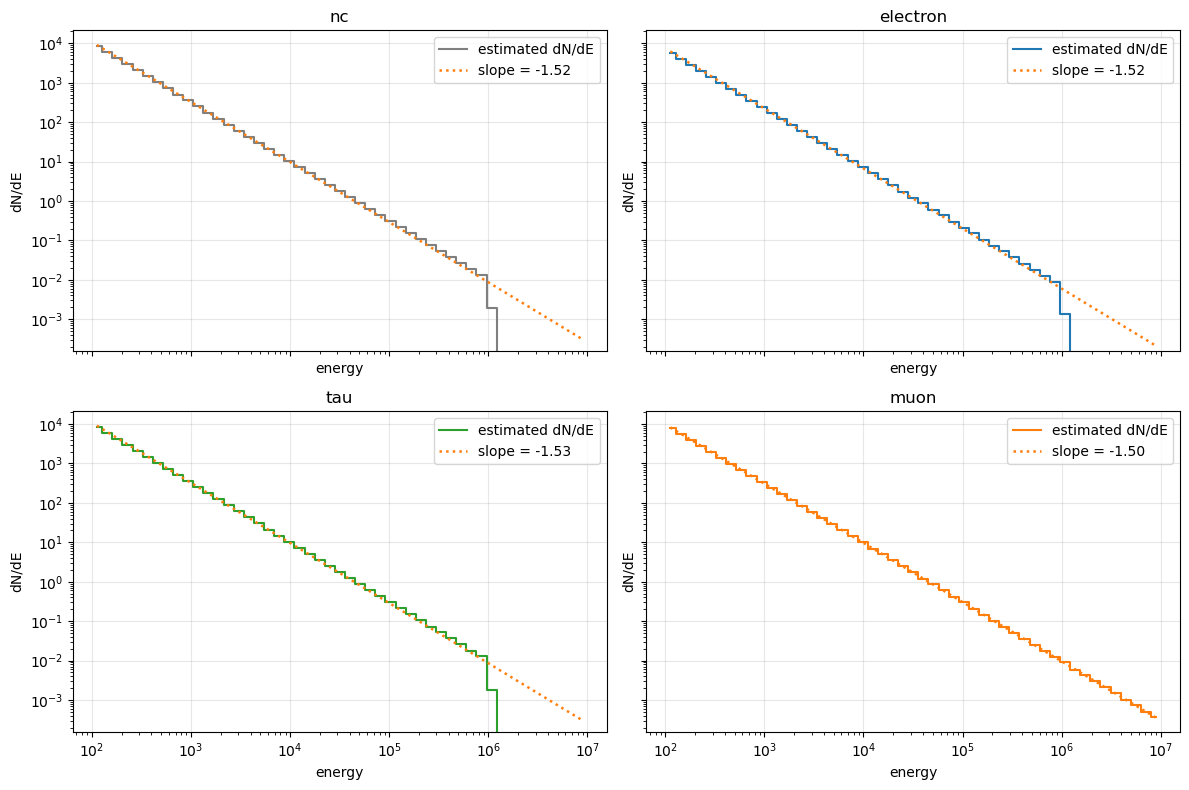

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, flavor in zip(axes, flavor_plot_order):
    color = flavor_colors[flavor]
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )
    energy = flavor_sample.loc[flavor_sample["energy"] > 0, "energy"]

    counts, edges = np.histogram(energy, bins=energy_bins)
    bin_widths = np.diff(edges)
    bin_centers = np.sqrt(edges[:-1] * edges[1:])
    dnde = counts / bin_widths
    nonzero = dnde > 0

    slope, intercept = np.polyfit(np.log10(bin_centers[nonzero]), np.log10(dnde[nonzero]), 1)
    fit = 10**intercept * bin_centers**slope

    ax.step(
        bin_centers,
        dnde,
        where="mid",
        color=color,
        linewidth=1.5,
        label="estimated dN/dE",
    )
    ax.plot(
        bin_centers,
        fit,
        linestyle=":",
        color="tab:orange",
        linewidth=1.8,
        label=f"slope = {slope:.2f}",
    )

    ax.set_title(flavor)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("energy")
    ax.set_ylabel("dN/dE")
    ax.legend()

plt.tight_layout()
plt.show()

## Check whether oneweight is only inverse generation

**Expectation.** Dividing `oneweight` by `E^1.5` removes the dominant inverse-generation trend expected from an `E^-1.5` generation spectrum. If LIW were only inverse generation, this ratio would be approximately flat. We expect it not to be flat, because LIW also contains interaction, cross-section, column-depth, and injection-geometry information.

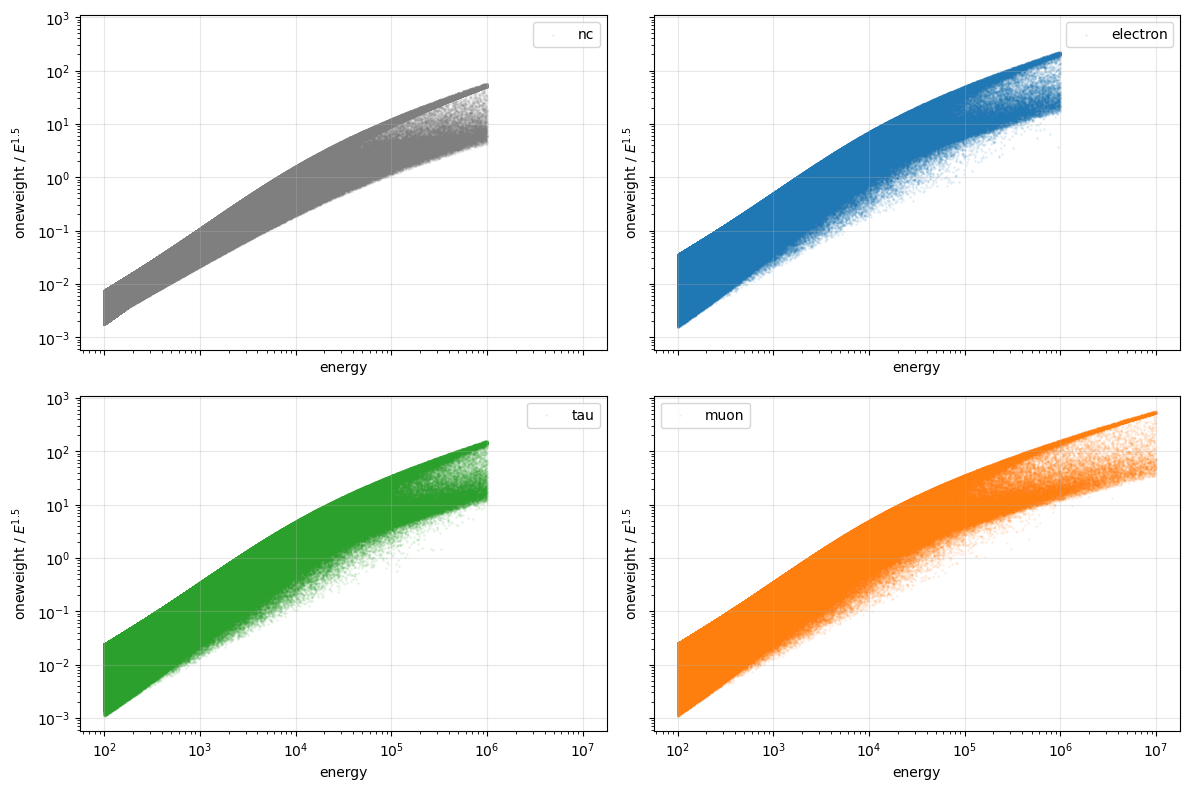

In [147]:
generated_power_index = 1.5

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, flavor in zip(axes, flavor_plot_order):
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )
    plot_sample = flavor_sample.loc[
        (flavor_sample["energy"] > 0) & (flavor_sample["oneweight"] > 0)
    ].copy()
    liw_over_generation = plot_sample["oneweight"] / plot_sample["energy"]**generated_power_index

    ax.scatter(
        plot_sample["energy"],
        liw_over_generation,
        s=1,
        alpha=0.08,
        color=flavor_colors[flavor],
        label=flavor,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("energy")
    ax.set_ylabel(r"oneweight / $E^{1.5}$")
    ax.legend()

plt.tight_layout()
plt.show()

## Energy vs total column depth by flavor

This compares generated event energy with the event `columnDepth` for each flavor.

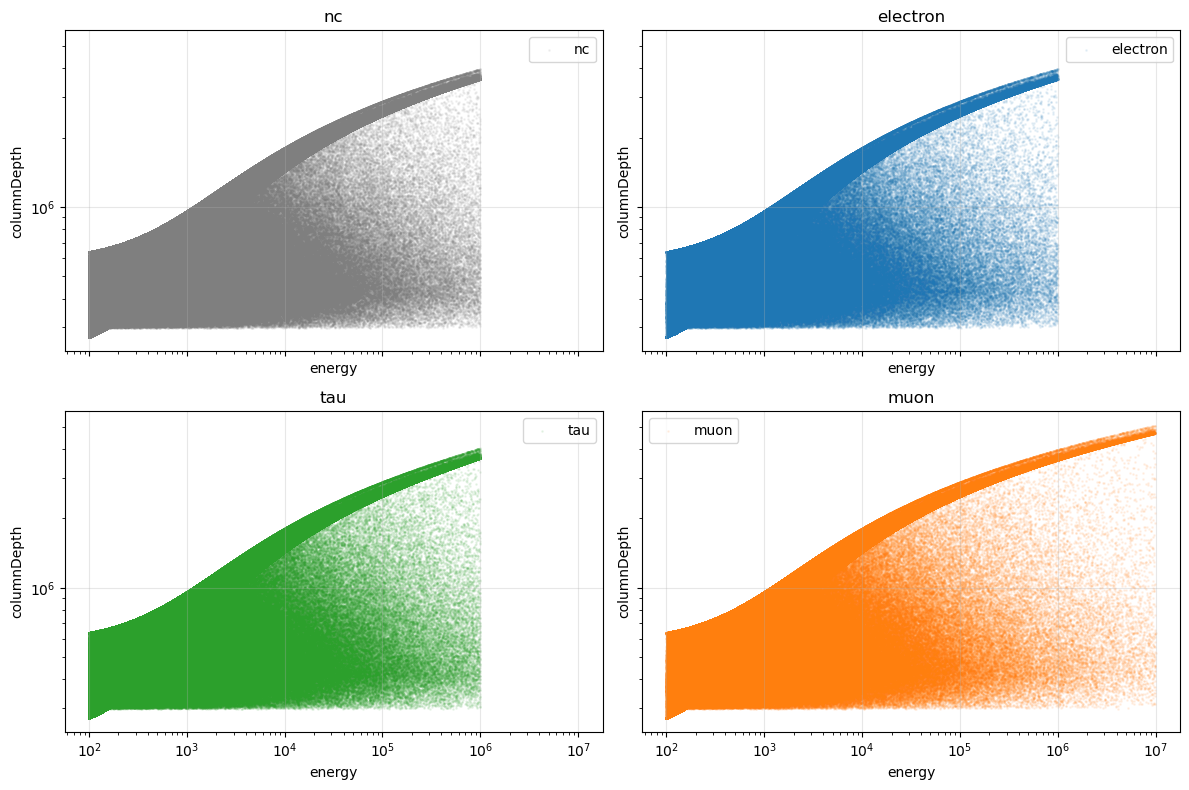

In [148]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, flavor in zip(axes, flavor_plot_order):
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )
    plot_sample = flavor_sample.loc[
        (flavor_sample["energy"] > 0) & (flavor_sample["columnDepth"] > 0)
    ]

    ax.scatter(
        plot_sample["energy"],
        plot_sample["columnDepth"],
        s=1,
        alpha=0.08,
        color=flavor_colors[flavor],
        label=flavor,
    )
    ax.set_title(flavor)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("energy")
    ax.set_ylabel("columnDepth")
    ax.legend()

plt.tight_layout()
plt.show()

## Zenith angle vs total column depth by flavor

This checks whether the high-`columnDepth` envelope is mostly controlled by event direction. `zenith` is converted from radians to degrees. The solid line shows the median `columnDepth` in zenith-angle bins, and the shaded band shows the 16th-84th percentile range.

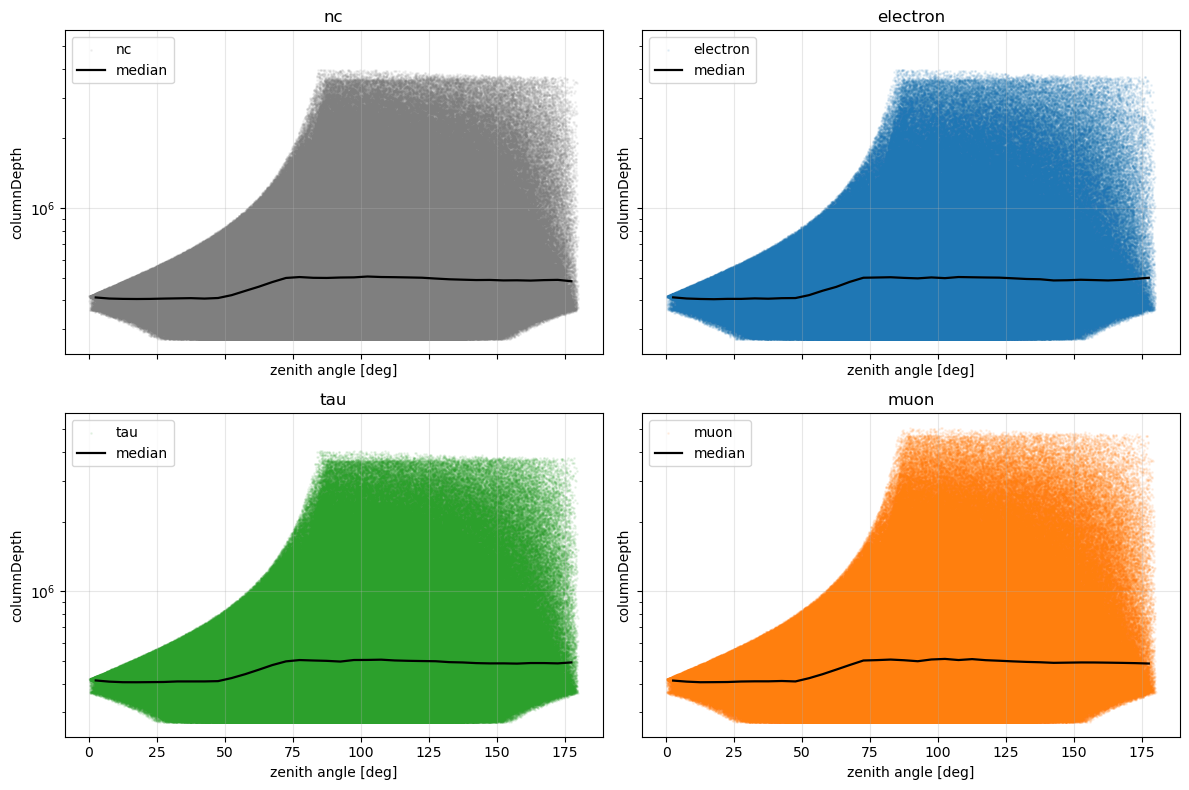

In [149]:
zenith_angle_bins = np.linspace(0, 180, 37)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, flavor in zip(axes, flavor_plot_order):
    flavor_sample = pd.concat(
        [
            weighted_flavor_splits[flavor]["neutrino"],
            weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    ).copy()
    flavor_sample["zenith_deg"] = np.degrees(flavor_sample["zenith"])

    plot_sample = flavor_sample.loc[
        np.isfinite(flavor_sample["zenith_deg"])
        & np.isfinite(flavor_sample["columnDepth"])
        & (flavor_sample["columnDepth"] > 0)
    ]

    bin_index = np.digitize(plot_sample["zenith_deg"], zenith_angle_bins) - 1

    bin_centers = []
    median = []

    for i in range(len(zenith_angle_bins) - 1):
        in_bin = bin_index == i
        if in_bin.sum() < 20:
            continue

        values = plot_sample.loc[in_bin, "columnDepth"]
        bin_centers.append(0.5 * (zenith_angle_bins[i] + zenith_angle_bins[i + 1]))
        median.append(np.percentile(values, 50))

    bin_centers = np.array(bin_centers)
    median = np.array(median)

    ax.scatter(
        plot_sample["zenith_deg"],
        plot_sample["columnDepth"],
        s=1,
        alpha=0.08,
        color=flavor_colors[flavor],
        label=flavor,
    )

    ax.plot(
        bin_centers,
        median,
        color="black",
        linewidth=1.6,
        label="median",
    )

    ax.set_title(flavor)
    ax.set_yscale("log")
    ax.set_xlabel("zenith angle [deg]")
    ax.set_ylabel("columnDepth")
    ax.legend()

plt.tight_layout()
plt.show()